In [ ]:
import os
import sys
import math
import torch
import random
import numpy as np
import torch.nn as nn
from pathlib import Path
import torch.nn.functional as F
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat, einsum

import training_runtime 
import inference_runtime
from rms_norm import RMSNorm


MODEL_CONFIGS = {
    "embed_dim"   : 2**5,   # 32
    "max_seq_len" : 2**6,   # 64
    "batch_size"  : 2**4,   # 16
    "vocab_size"  : 2**11,  # 2048
    "learning_rate" : 1e-3,
    "save_path" : "../models/level2_fixed_positional.pt",
    "loss_history" : "../models/level2_fixed_positional_loss_history.txt",
}



# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)


cuda


In [2]:
class Level2PositionLM(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.vocab_size = MODEL_CONFIGS["vocab_size"]
        self.embed_dim = MODEL_CONFIGS["embed_dim"]
        self.max_seq_len = MODEL_CONFIGS["max_seq_len"]


        # Token Embedding lookup (learnable parameters)
        self.embed = nn.Parameter(torch.randn(self.vocab_size, self.embed_dim) * 0.02)

        self.rms_norm = RMSNorm(self.embed_dim)

        # Unembedding Projection matrix (learnable parameters)
        self.unembed = nn.Parameter(torch.randn(self.embed_dim, self.vocab_size) * 0.02)

        # ---

        # Pre-computing Fixed Sinusoidal Positional Encodings (not learnable parameters)
        pos_enc = torch.zeros(self.max_seq_len, self.embed_dim)
        position = torch.arange(0, self.max_seq_len, dtype=torch.float).unsqueeze(1) # Shape: (max_seq_len, 1)

        
        # Geometric progression division term: 10000^(2i/d_embed)
        # Operating in log-space for numerical stability
        div_term = torch.exp(torch.arange(0, self.embed_dim, step=2).float() *
                              (-math.log(10000.0) / self.embed_dim)
                            ) # Shape: (embed_dim/2)

        # Apply sine to even indices,
        pos_enc[:, 0::2] = torch.sin(position * div_term)
        # cosine to odd indices
        pos_enc[:, 1::2] = torch.cos(position * div_term)

        # Register as buffer: model state, non-learnable(gets no gradients)
        self.register_buffer('pos_enc', pos_enc)

  
        
    def forward(self, idx: torch.Tensor)-> torch.Tensor:

        batch_size, seq_len  = idx.shape

        # Assert to prevent sequence lengths exceeding pre-computed PE capacity
        assert seq_len <= self.max_seq_len, f"Sequence length {seq_len} exceeds maximum sequence length {self.max_seq_len}"

        # Token embedding lookup -> Shape: (batch_size, seq_len, embed_dim)
        x_token = self.embed[idx]

        # Positional encodings: (seq_len, embed_dim)
        x_pos = self.pos_enc[:seq_len]

        x_pos = rearrange(self.pos_enc[:seq_len], "seq_len embed_dim -> 1 seq_len embed_dim")
        x = x_token + x_pos  # PyTorch automatically broadcasts the batch dimension of 1 to batch_size

        x_norm = self.rms_norm(x)

        # Unembed projection
        logits = einsum(x_norm, self.unembed, 
                        "batch_size seq_len embed_dim, embed_dim vocab_size"
                        " -> "
                        "batch_size seq_len vocab_size")
        
        return logits


Step 0000 | Batch Loss: 7.6379 nats
Step 0005 | Batch Loss: 7.5813 nats
Step 0010 | Batch Loss: 7.5420 nats
Step 0015 | Batch Loss: 7.5157 nats
Step 0020 | Batch Loss: 7.4729 nats
Step 0025 | Batch Loss: 7.4441 nats
Step 0030 | Batch Loss: 7.3991 nats
Step 0035 | Batch Loss: 7.3645 nats
Step 0040 | Batch Loss: 7.3400 nats
Step 0045 | Batch Loss: 7.3125 nats
Step 0050 | Batch Loss: 7.2634 nats
Step 0055 | Batch Loss: 7.2477 nats
Step 0060 | Batch Loss: 7.2439 nats
Step 0065 | Batch Loss: 7.2453 nats
Step 0070 | Batch Loss: 7.2066 nats
Step 0075 | Batch Loss: 7.1743 nats
Step 0080 | Batch Loss: 7.1778 nats
Step 0085 | Batch Loss: 7.1437 nats
Step 0090 | Batch Loss: 7.1816 nats
Step 0095 | Batch Loss: 7.0953 nats
Step 0099 | Batch Loss: 7.1153 nats

Saving model weights to: ../models/level2_fixed_positional.pt
Loss history successfully saved to ../models/level2_fixed_positional_loss_history.txt
Loaded 100 steps from ../models/level2_fixed_positional_loss_history.txt


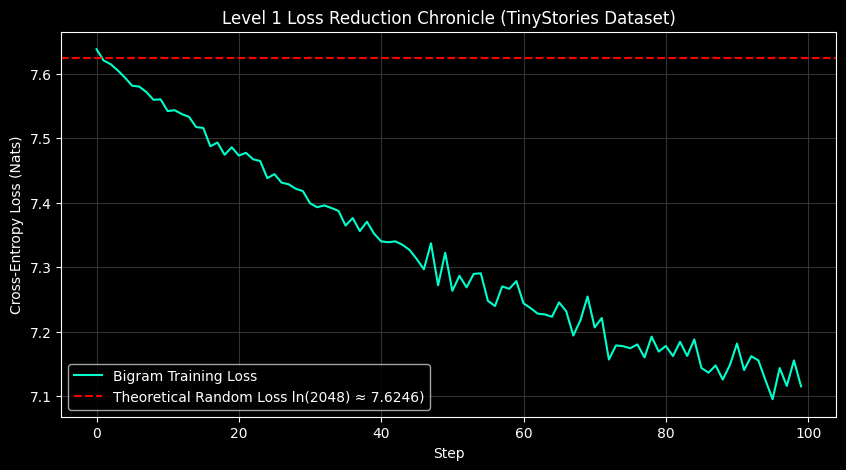

In [ ]:
model = Level2PositionLM()
configs = MODEL_CONFIGS

training_runtime.train_and_save_model(model, configs, device, 100)
training_runtime.plot_loss_history(configs)
